In [1]:
import pandas as pd

df = pd.read_csv('/content/heart.csv')
display(df.head())

,Patient ID,Age,Sex,Cholesterol,Blood Pressure,Heart Rate,Diabetes,Family History,Smoking,Obesity,...,Sedentary Hours Per Day,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Country,Continent,Hemisphere,Heart Attack Risk
0,BMW7812,67,Male,208,158/88,72,0,0,1,0,...,6.615001,261404,31.251233,286,0,6,Argentina,South America,Southern Hemisphere,0
1,CZE1114,21,Male,389,165/93,98,1,1,1,1,...,4.963459,285768,27.194973,235,1,7,Canada,North America,Northern Hemisphere,0
2,BNI9906,21,Female,324,174/99,72,1,0,0,0,...,9.463426,235282,28.176571,587,4,4,France,Europe,Northern Hemisphere,0
3,JLN3497,84,Male,383,163/100,73,1,1,1,0,...,7.648981,125640,36.464704,378,3,4,Canada,North America,Northern Hemisphere,0
4,GFO8847,66,Male,318,91/88,93,1,1,1,1,...,1.514821,160555,21.809144,231,1,5,Thailand,Asia,Northern Hemisphere,0


In [2]:
print("Data Types:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDescriptive Statistics:")
print(df.describe())

Data Types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 26 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Patient ID                       8763 non-null   object 
 1   Age                              8763 non-null   int64  
 2   Sex                              8763 non-null   object 
 3   Cholesterol                      8763 non-null   int64  
 4   Blood Pressure                   8763 non-null   object 
 5   Heart Rate                       8763 non-null   int64  
 6   Diabetes                         8763 non-null   int64  
 7   Family History                   8763 non-null   int64  
 8   Smoking                          8763 non-null   int64  
 9   Obesity                          8763 non-null   int64  
 10  Alcohol Consumption              8763 non-null   int64  
 11  Exercise Hours Per Week          8763 non-null   float64
 12  Diet    

In [3]:
print("Original DataFrame shape:", df.shape)

# 1. Drop 'Patient ID' column
df = df.drop('Patient ID', axis=1)
print("DataFrame shape after dropping 'Patient ID':", df.shape)

# 2. Process 'Blood Pressure' column
# a. Split 'Blood Pressure' into 'Systolic_BP' and 'Diastolic_BP'
df[['Systolic_BP', 'Diastolic_BP']] = df['Blood Pressure'].str.split('/', expand=True)

# b. Convert to numeric
df['Systolic_BP'] = pd.to_numeric(df['Systolic_BP'])
df['Diastolic_BP'] = pd.to_numeric(df['Diastolic_BP'])

# c. Drop the original 'Blood Pressure' column
df = df.drop('Blood Pressure', axis=1)
print("DataFrame shape after processing 'Blood Pressure':", df.shape)

# 3. Identify and apply one-hot encoding to specified categorical columns
categorical_cols = ['Sex', 'Diet', 'Country', 'Continent', 'Hemisphere']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=False) # Keep all categories
print("DataFrame shape after one-hot encoding:", df.shape)

# 4. Display the first few rows of the updated DataFrame and its information
print("\nUpdated DataFrame head:")
display(df.head())

print("\nUpdated DataFrame info:")
print(df.info())

Original DataFrame shape: (8763, 26)
DataFrame shape after dropping 'Patient ID': (8763, 25)
DataFrame shape after processing 'Blood Pressure': (8763, 26)
DataFrame shape after one-hot encoding: (8763, 54)

Updated DataFrame head:


,Age,Cholesterol,Heart Rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Previous Heart Problems,...,Country_United States,Country_Vietnam,Continent_Africa,Continent_Asia,Continent_Australia,Continent_Europe,Continent_North America,Continent_South America,Hemisphere_Northern Hemisphere,Hemisphere_Southern Hemisphere
0,67,208,72,0,0,1,0,0,4.168189,0,...,False,False,False,False,False,False,False,True,False,True
1,21,389,98,1,1,1,1,1,1.813242,1,...,False,False,False,False,False,False,True,False,True,False
2,21,324,72,1,0,0,0,0,2.078353,1,...,False,False,False,False,False,True,False,False,True,False
3,84,383,73,1,1,1,0,1,9.828130,1,...,False,False,False,False,False,False,True,False,True,False
4,66,318,93,1,1,1,1,0,5.804299,1,...,False,False,False,True,False,False,False,False,True,False



Updated DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 54 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Age                              8763 non-null   int64  
 1   Cholesterol                      8763 non-null   int64  
 2   Heart Rate                       8763 non-null   int64  
 3   Diabetes                         8763 non-null   int64  
 4   Family History                   8763 non-null   int64  
 5   Smoking                          8763 non-null   int64  
 6   Obesity                          8763 non-null   int64  
 7   Alcohol Consumption              8763 non-null   int64  
 8   Exercise Hours Per Week          8763 non-null   float64
 9   Previous Heart Problems          8763 non-null   int64  
 10  Medication Use                   8763 non-null   int64  
 11  Stress Level                     8763 non-null   int64  


## Conduct Exploratory Data Analysis (EDA).

### Subtask:
Visualize distributions of key features, analyze relationships between variables, and identify potential insights related to heart attack risk.


**Reasoning**:
To begin the EDA process, I will import the necessary libraries, `matplotlib.pyplot` and `seaborn`, which are essential for data visualization. Then I will generate a count plot for `Heart Attack Risk` to check for class imbalance.



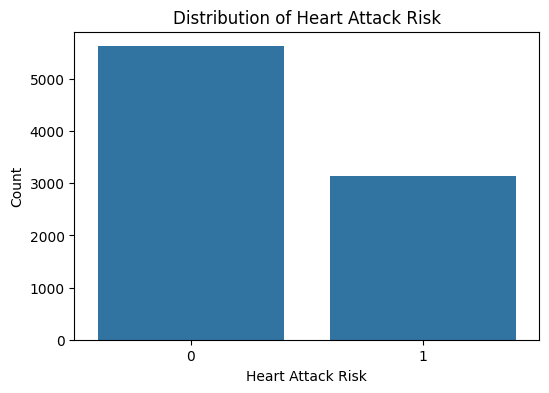

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize the distribution of the target variable 'Heart Attack Risk'
plt.figure(figsize=(6, 4))
sns.countplot(x='Heart Attack Risk', data=df)
plt.title('Distribution of Heart Attack Risk')
plt.xlabel('Heart Attack Risk')
plt.ylabel('Count')
plt.show()


**Reasoning**:
I will create histograms for the specified key numerical features ('Age', 'Cholesterol', 'Heart Rate', 'Systolic_BP', 'Diastolic_BP', and 'BMI') to visualize their distributions, as per the instructions.



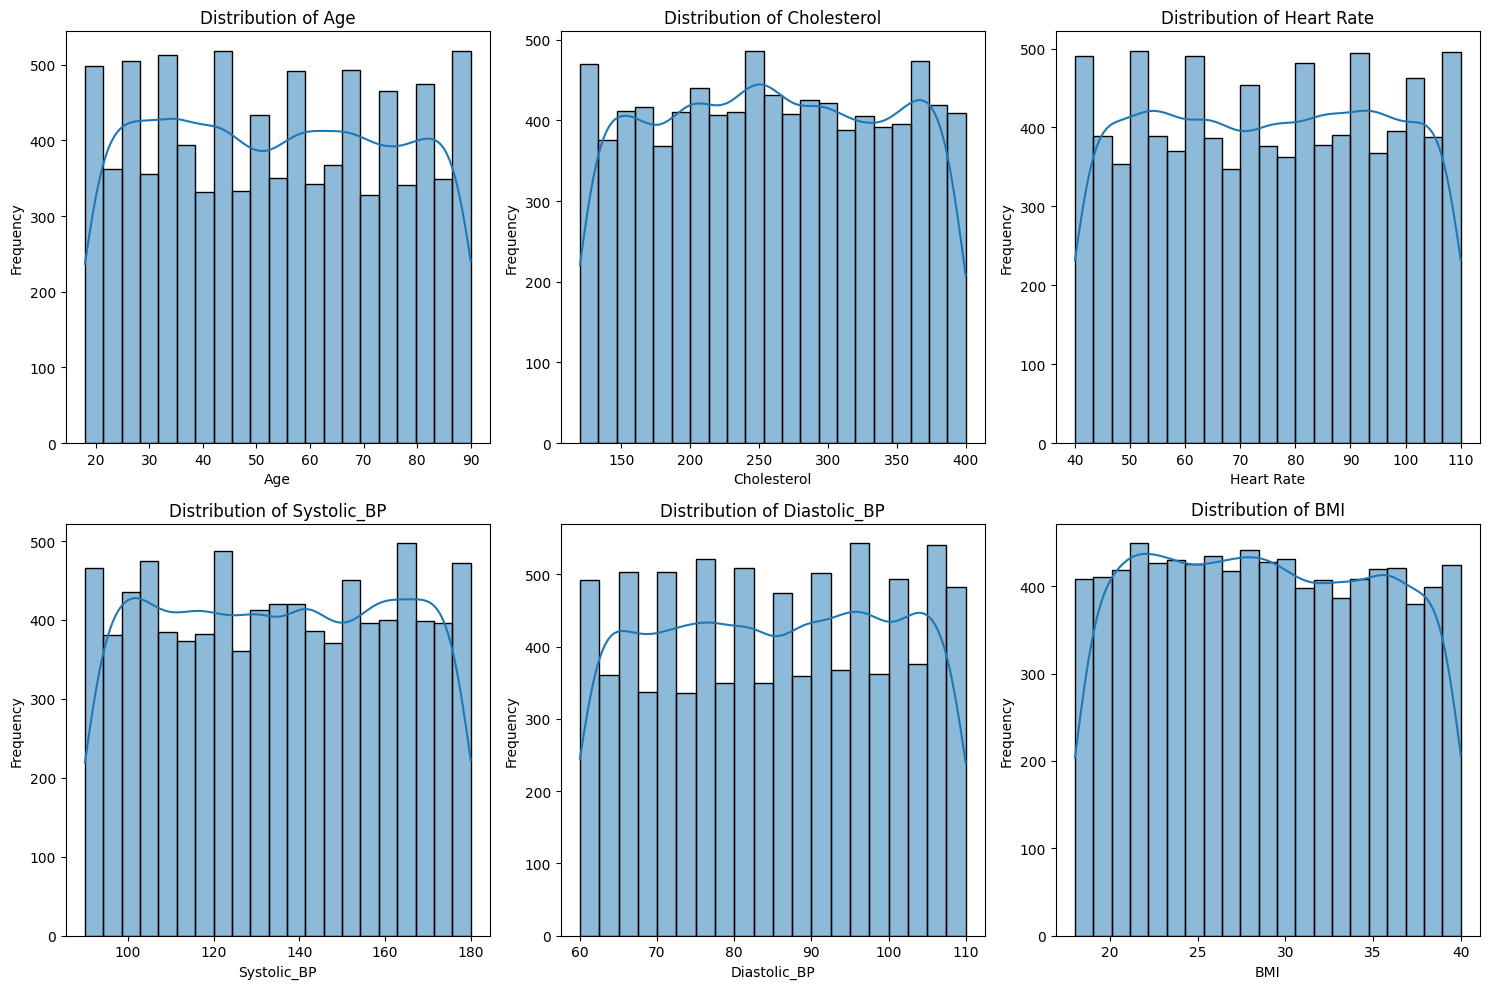

In [5]:
numerical_features = ['Age', 'Cholesterol', 'Heart Rate', 'Systolic_BP', 'Diastolic_BP', 'BMI']

plt.figure(figsize=(15, 10))
for i, feature in enumerate(numerical_features):
    plt.subplot(2, 3, i + 1) # Arrange in 2 rows, 3 columns
    sns.histplot(df[feature], kde=True)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

**Reasoning**:
To analyze the relationship between 'Heart Attack Risk' and key numerical features, I will generate box plots for 'Age', 'Cholesterol', 'Heart Rate', 'Income', and 'BMI' against 'Heart Attack Risk'.



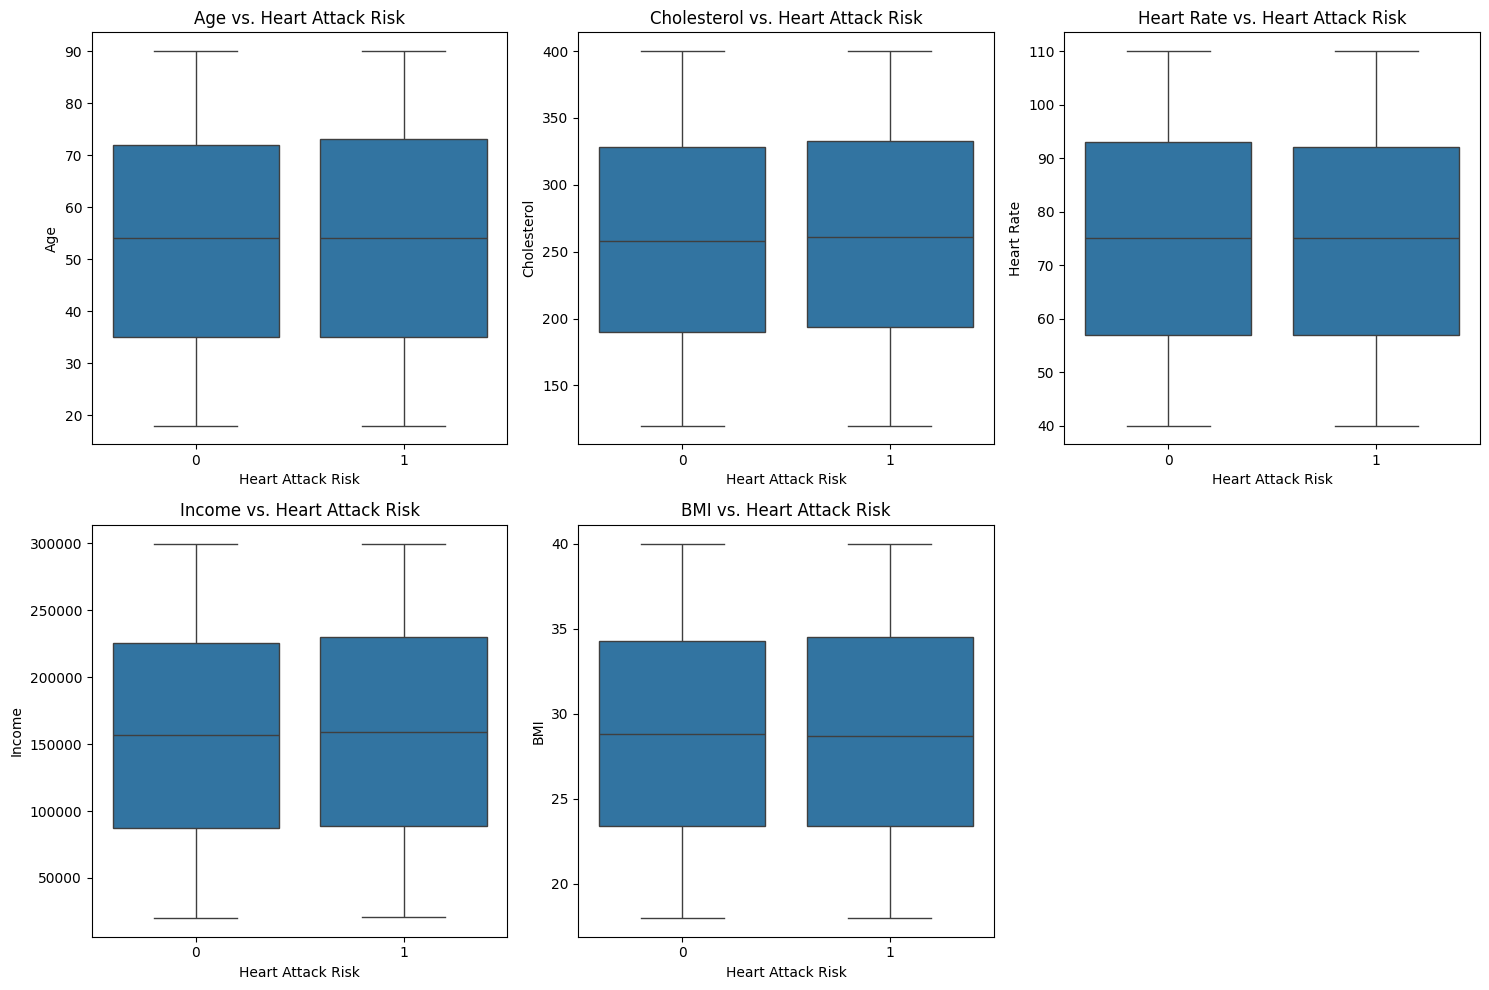

In [6]:
numerical_features_for_boxplot = ['Age', 'Cholesterol', 'Heart Rate', 'Income', 'BMI']

plt.figure(figsize=(15, 10))
for i, feature in enumerate(numerical_features_for_boxplot):
    plt.subplot(2, 3, i + 1) # Arrange in 2 rows, 3 columns
    sns.boxplot(x='Heart Attack Risk', y=feature, data=df)
    plt.title(f'{feature} vs. Heart Attack Risk')
    plt.xlabel('Heart Attack Risk')
    plt.ylabel(feature)
plt.tight_layout()
plt.show()

**Reasoning**:
To identify strong correlations between numerical features, I will generate a heatmap of the correlation matrix. First, I need to filter out boolean columns and the target variable ('Heart Attack Risk') from the DataFrame to ensure only relevant numerical features are included in the correlation calculation.



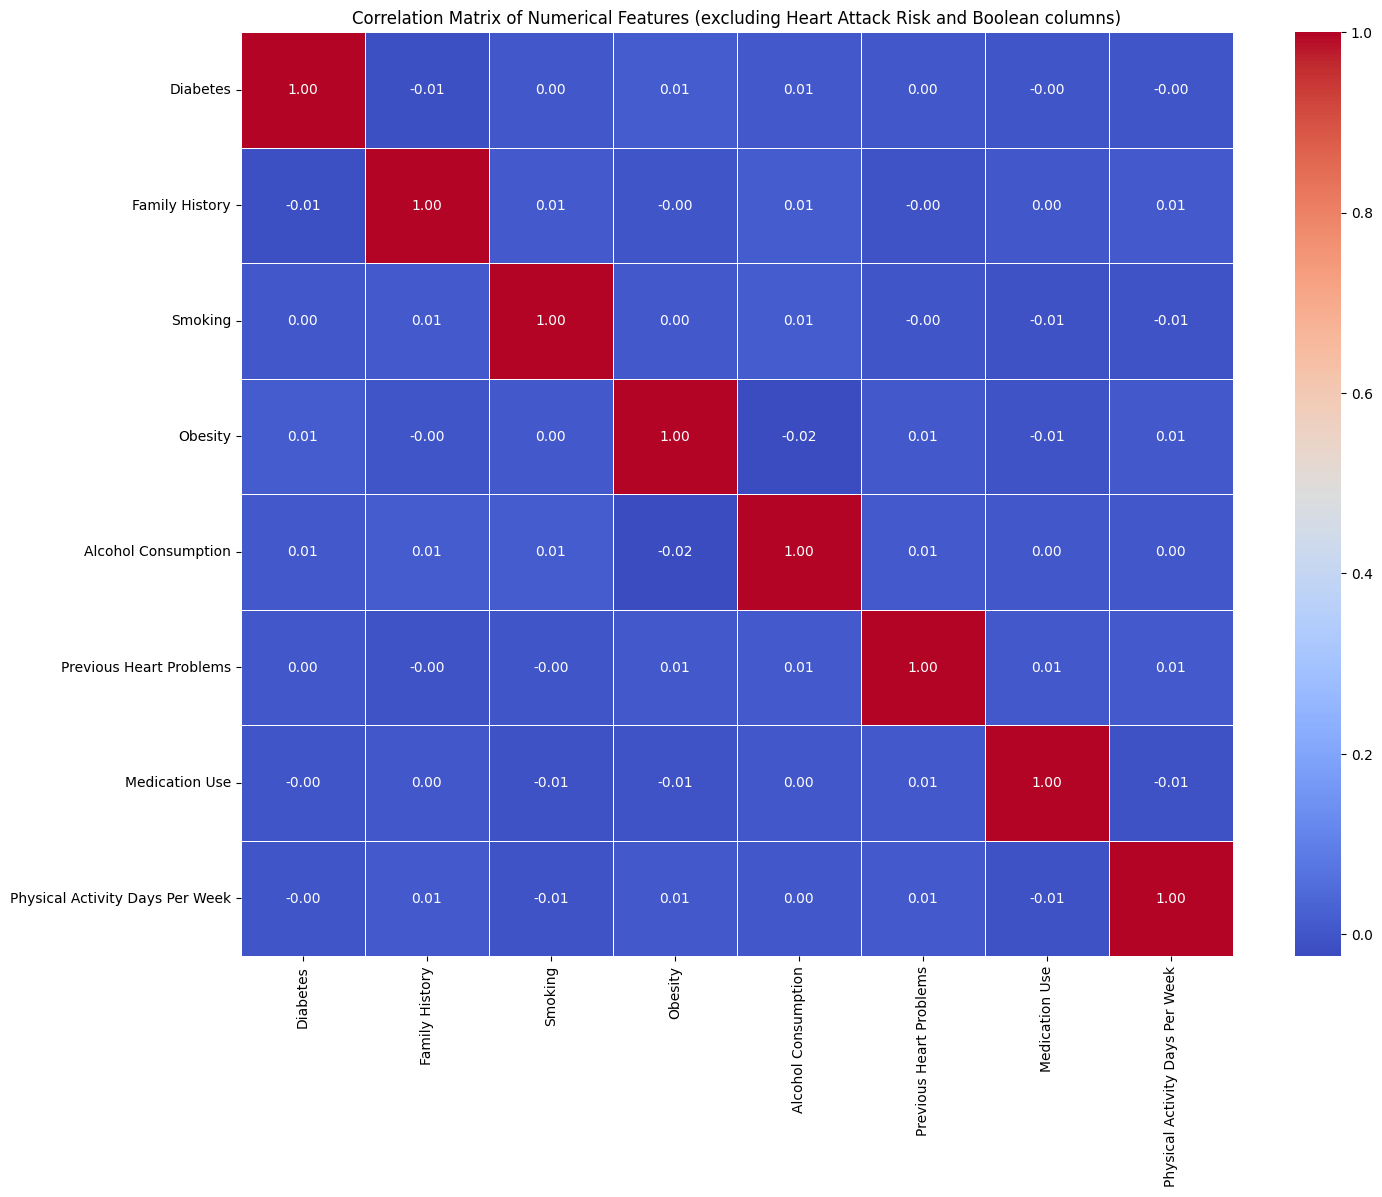

In [7]:
numerical_df = df.select_dtypes(include=['int64', 'float64']) # Select only numerical columns

# Exclude boolean columns by identifying them and dropping from numerical_df if they are not already excluded
bool_cols = numerical_df.columns[numerical_df.apply(lambda x: x.astype(bool).all() or not x.astype(bool).any()).values] # Identify columns that are purely boolean (0 or 1)
numerical_df = numerical_df.drop(columns=bool_cols, errors='ignore')

# Also exclude 'Heart Attack Risk' if it's still present, as it's the target variable
if 'Heart Attack Risk' in numerical_df.columns:
    numerical_df = numerical_df.drop(columns=['Heart Attack Risk'])

# Calculate the correlation matrix
corr_matrix = numerical_df.corr()

# Plot the heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Numerical Features (excluding Heart Attack Risk and Boolean columns)')
plt.show()

## Perform feature selection and engineering.

### Subtask:
Separate features and target, scale numerical features, and consider feature selection based on correlation.


**Reasoning**:
First, I will separate the features (X) and the target variable (y) from the DataFrame `df` based on the 'Heart Attack Risk' column. Then, I will identify the numerical features specified for scaling. After that, I will import and instantiate `StandardScaler` to apply it to these numerical features in `X`, ensuring other columns remain untouched.



In [8]:
from sklearn.preprocessing import StandardScaler

# 1. Separate features (X) and target (y)
X = df.drop('Heart Attack Risk', axis=1)
y = df['Heart Attack Risk']

print("Shape of X (features):", X.shape)
print("Shape of y (target):", y.shape)

# 2. Identify the numerical features that need to be scaled
numerical_features_to_scale = [
    'Age', 'Cholesterol', 'Heart Rate', 'Exercise Hours Per Week',
    'Stress Level', 'Sedentary Hours Per Day', 'Income', 'BMI',
    'Triglycerides', 'Physical Activity Days Per Week', 'Sleep Hours Per Day',
    'Systolic_BP', 'Diastolic_BP'
]

# 3. and 4. Instantiate StandardScaler
scaler = StandardScaler()

# 5. Apply the StandardScaler to the identified numerical features in X
X[numerical_features_to_scale] = scaler.fit_transform(X[numerical_features_to_scale])

print("\nFirst 5 rows of X after scaling numerical features:")
display(X.head())

print("\nDescriptive statistics of scaled numerical features:")
display(X[numerical_features_to_scale].describe())

Shape of X (features): (8763, 53)
Shape of y (target): (8763,)

First 5 rows of X after scaling numerical features:


,Age,Cholesterol,Heart Rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Previous Heart Problems,...,Country_United States,Country_Vietnam,Continent_Africa,Continent_Asia,Continent_Australia,Continent_Europe,Continent_North America,Continent_South America,Hemisphere_Northern Hemisphere,Hemisphere_Southern Hemisphere
0,0.625557,-0.641579,-0.147042,0,0,1,0,0,-1.010838,0,...,False,False,False,False,False,False,False,True,False,True
1,-1.539322,1.596895,1.118179,1,1,1,1,1,-1.418027,1,...,False,False,False,False,False,False,True,False,True,False
2,-1.539322,0.793023,-0.147042,1,0,0,0,0,-1.372188,1,...,False,False,False,False,False,True,False,False,True,False
3,1.425621,1.522691,-0.098380,1,1,1,0,1,-0.032188,1,...,False,False,False,False,False,False,True,False,True,False
4,0.578495,0.718820,0.874867,1,1,1,1,0,-0.727941,1,...,False,False,False,True,False,False,False,False,True,False



Descriptive statistics of scaled numerical features:


,Age,Cholesterol,Heart Rate,Exercise Hours Per Week,Stress Level,Sedentary Hours Per Day,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Systolic_BP,Diastolic_BP
count,8.763000e+03,8.763000e+03,8.763000e+03,8.763000e+03,8.763000e+03,8.763000e+03,8.763000e+03,8.763000e+03,8.763000e+03,8.763000e+03,8.763000e+03,8.763000e+03,8.763000e+03
mean,-5.756994e-17,5.594825e-17,1.763586e-16,1.232483e-16,-6.324584e-17,-2.756870e-17,1.652095e-16,-3.462305e-16,-5.716451e-17,-2.594701e-17,-1.824399e-16,3.304190e-16,-3.133913e-16
std,1.000057e+00,1.000057e+00,1.000057e+00,1.000057e+00,1.000057e+00,1.000057e+00,1.000057e+00,1.000057e+00,1.000057e+00,1.000057e+00,1.000057e+00,1.000057e+00,1.000057e+00
min,-1.680510e+00,-1.729898e+00,-1.704237e+00,-1.731130e+00,-1.563129e+00,-1.728837e+00,-1.715281e+00,-1.723282e+00,-1.732748e+00,-1.528843e+00,-1.520604e+00,-1.710750e+00,-1.714130e+00
25%,-8.804460e-01,-8.394550e-01,-8.769771e-01,-8.701960e-01,-8.636957e-01,-8.640384e-01,-8.682223e-01,-8.654242e-01,-8.589480e-01,-6.526332e-01,-1.017677e+00,-8.757873e-01,-8.964538e-01
50%,1.374337e-02,-1.084870e-02,-1.055100e-03,9.557563e-03,-1.642626e-01,-1.732987e-02,-4.929614e-03,-1.937807e-02,-3.026125e-03,-2.145280e-01,-1.182278e-02,-2.871477e-03,-1.063735e-02
75%,8.608701e-01,8.672267e-01,8.748669e-01,8.707198e-01,8.848870e-01,8.728487e-01,8.624216e-01,8.598357e-01,8.685392e-01,6.616823e-01,9.940317e-01,8.700444e-01,8.751790e-01
max,1.707997e+00,1.732935e+00,1.702127e+00,1.726389e+00,1.584320e+00,1.732644e+00,1.758592e+00,1.757569e+00,1.708818e+00,1.537893e+00,1.496959e+00,1.705007e+00,1.692856e+00


**Reasoning**:
I will identify and display pairs of highly correlated features from the `corr_matrix` to understand potential multicollinearity and inform future feature selection decisions, as instructed by the subtask. After identifying highly correlated features, the current subtask of feature selection and engineering will be completed.



In [9]:
print("\nHIGHLY CORRELATED FEATURES (absolute correlation > 0.8):")

highly_correlated_features = set()
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > 0.8:
            colname1 = corr_matrix.columns[i]
            colname2 = corr_matrix.columns[j]
            print(f"  - {colname1} and {colname2}: {corr_matrix.iloc[i, j]:.2f}")
            highly_correlated_features.add(colname1)
            highly_correlated_features.add(colname2)

if not highly_correlated_features:
    print("  No highly correlated features found (absolute correlation > 0.8).")


HIGHLY CORRELATED FEATURES (absolute correlation > 0.8):
  No highly correlated features found (absolute correlation > 0.8).


## Build and train a machine learning model.

### Subtask:
Develop and train a model to predict 'Heart Attack Risk' based on the prepared features.


**Reasoning**:
To develop and train a machine learning model, I will first split the data into training and testing sets to prepare it for model training. Then, I will instantiate a RandomForestClassifier and train it using the training data.



In [10]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# 1. Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

# 2. Instantiate RandomForestClassifier
model = RandomForestClassifier(random_state=42)

# 3. Train the RandomForestClassifier model
model.fit(X_train, y_train)

print("Model training complete.")

Shape of X_train: (7010, 53)
Shape of X_test: (1753, 53)
Shape of y_train: (7010,)
Shape of y_test: (1753,)
Model training complete.
